In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
print("Current working directory:")
print(os.getcwd())

Current working directory:
/Users/palaksharma/aging-clock-env


In [3]:
aging_data_path = Path(
    "/Users/palaksharma/single-cell-aging-clock/data/processed/tabula_muris_senis_dev_subset.h5ad"
)

print("File exists:", aging_data_path.exists())

File exists: True


In [4]:
aging_data = sc.read_h5ad(aging_data_path)

print(aging_data)

AnnData object with n_obs × n_vars = 5218 × 22966
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'age_months'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'age_colors', 'cell_ontology_class_colors', 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [5]:
print(aging_data.obs.columns.tolist())

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'age_months']


In [6]:
aging_data.obs[["age", "age_months", "tissue", "cell_ontology_class"]].head()

,age,age_months,tissue,cell_ontology_class
index,,,,
A10_B000229_B009899_S10.mm10-plus-4-0,18m,18,Lung,bronchial smooth muscle cell
A10_B000248_B009895_S10.mm10-plus-4-0,18m,18,Lung,fibroblast of lung
A10_B000265_B009901_S10.mm10-plus-4-0,18m,18,Lung,bronchial smooth muscle cell
A10_B000266_B009900_S10.mm10-plus-4-0,18m,18,Lung,bronchial smooth muscle cell
A10_B002258_B009940_S10.mm10-plus-4-0,18m,18,Lung,bronchial smooth muscle cell


In [7]:
print(aging_data.obs["age"].value_counts())

age
18m    1960
24m    1877
3m     1381
Name: count, dtype: int64


In [8]:
print(aging_data.obs["age_months"].value_counts().sort_index())

age_months
3     1381
18    1960
24    1877
Name: count, dtype: int64


In [10]:
print(aging_data.obs["cell_ontology_class"].value_counts().head(20))

cell_ontology_class
bronchial smooth muscle cell                       2117
fibroblast of lung                                  483
myeloid dendritic cell                              373
adventitial cell                                    289
B cell                                              276
classical monocyte                                  202
type II pneumocyte                                  167
vein endothelial cell                               152
non-classical monocyte                              149
neutrophil                                          123
CD8-positive, alpha-beta T cell                     119
smooth muscle cell of the pulmonary artery          111
endothelial cell of lymphatic vessel                 99
dendritic cell                                       62
CD4-positive, alpha-beta T cell                      59
NK cell                                              52
ciliated columnar cell of tracheobronchial tree      52
pulmonary interstitial fibro

In [12]:
print("Shape of expression matrix:", aging_data.X.shape)

print("Min value:", aging_data.X.min())
print("Maxi value:", aging_data.X.max())

Shape of expression matrix: (5218, 22966)
Min value: 0.0
Maxi value: 10.0


In [13]:
aging_data_processed = aging_data.copy()

print(aging_data_processed)

AnnData object with n_obs × n_vars = 5218 × 22966
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'age_months'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'age_colors', 'cell_ontology_class_colors', 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [14]:
aging_data_processed.var["mt"] = aging_data_processed.var_names.str.startswith(("mt-", "Mt-"))

print("Number of mitochondrial genes found:")
print(aging_data_processed.var["mt"].sum())

Number of mitochondrial genes found:
0


In [15]:
sc.pp.calculate_qc_metrics(
    aging_data_processed,
    qc_vars=["mt"],
    inplace=True
)

In [16]:
aging_data_processed.obs[
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
].head()

,n_genes_by_counts,total_counts,pct_counts_mt
index,,,
A10_B000229_B009899_S10.mm10-plus-4-0,1464,3106.374268,0.0
A10_B000248_B009895_S10.mm10-plus-4-0,1445,3091.449951,0.0
A10_B000265_B009901_S10.mm10-plus-4-0,3839,4870.176270,0.0
A10_B000266_B009900_S10.mm10-plus-4-0,2940,5624.985352,0.0
A10_B002258_B009940_S10.mm10-plus-4-0,3122,4734.306152,0.0


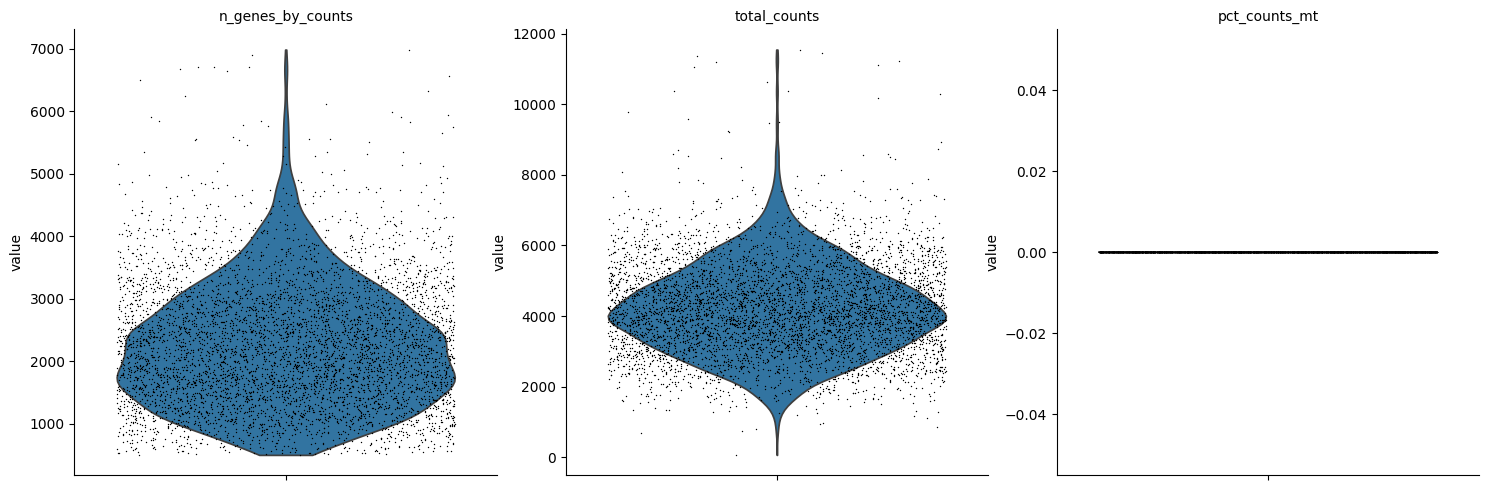

In [17]:
sc.pl.violin(
    aging_data_processed,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

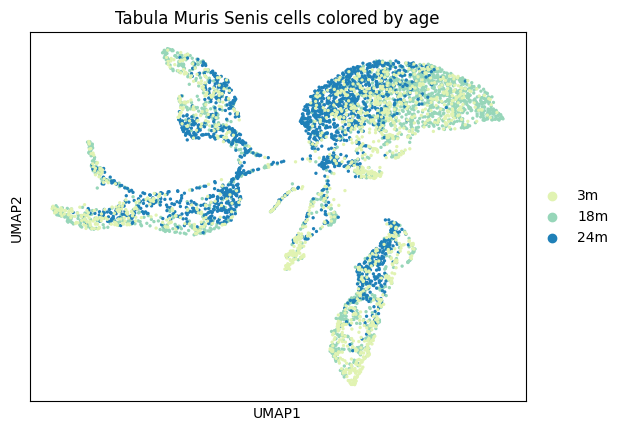

In [19]:
sc.pl.umap(
    aging_data,
    color="age",
    title="Tabula Muris Senis cells colored by age"
)

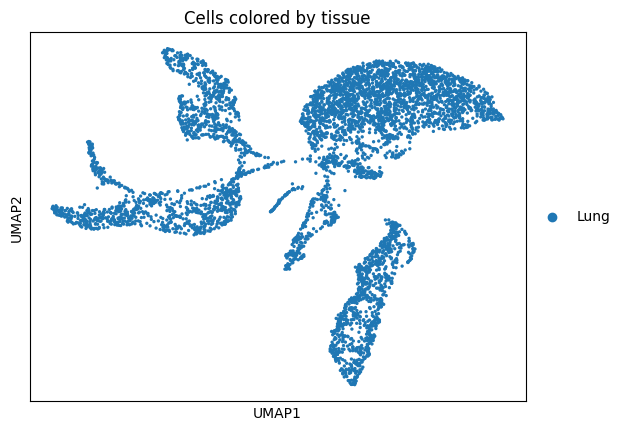

In [20]:
sc.pl.umap(
    aging_data,
    color="tissue",
    title="Cells colored by tissue"
)

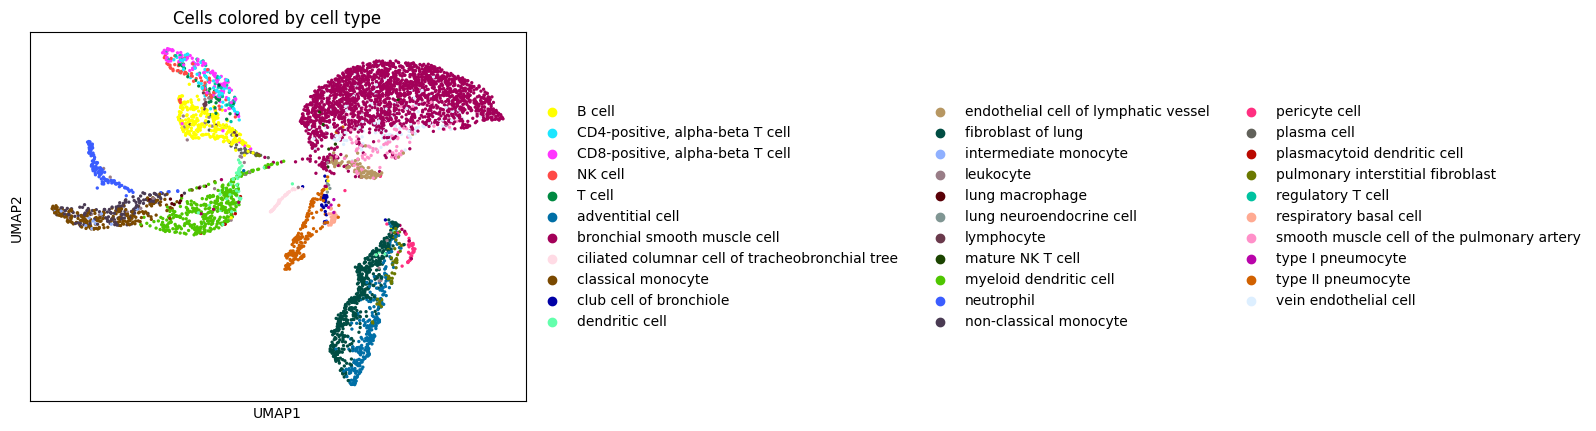

In [21]:
sc.pl.umap(
    aging_data,
    color="cell_ontology_class",
    title="Cells colored by cell type",
    legend_loc="right margin"
)

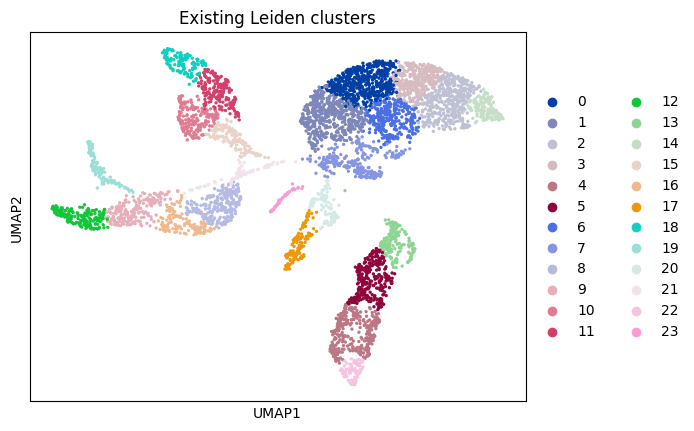

In [22]:
sc.pl.umap(
    aging_data,
    color="leiden",
    title="Existing Leiden clusters"
)

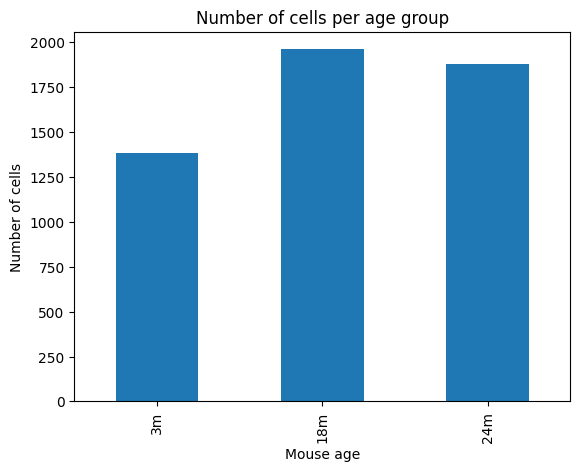

In [23]:
age_counts = aging_data.obs["age"].value_counts().sort_index()

age_counts.plot(kind="bar")

plt.title("Number of cells per age group")
plt.xlabel("Mouse age")
plt.ylabel("Number of cells")
plt.show()

In [24]:
tissue_age_table = pd.crosstab(
    aging_data.obs["tissue"],
    aging_data.obs["age"]
)

tissue_age_table

age,3m,18m,24m
tissue,,,
Lung,1381,1960,1877


In [25]:
cell_type_age_table = pd.crosstab(
    aging_data.obs["cell_ontology_class"],
    aging_data.obs["age"]
)

cell_type_age_table.head(20)

age,3m,18m,24m
cell_ontology_class,,,
B cell,55,77,144
"CD4-positive, alpha-beta T cell",36,22,1
"CD8-positive, alpha-beta T cell",9,48,62
NK cell,27,18,7
T cell,1,11,16
adventitial cell,140,98,51
bronchial smooth muscle cell,420,944,753
ciliated columnar cell of tracheobronchial tree,21,14,17
classical monocyte,68,80,54
